# Task 2 — Trip segmentation experiments

ทดลองวิธีแบ่ง trip หลายแบบจาก Unified Stream ของ Task 1 แล้วเปรียบเทียบกับ `TripSegmenter` ที่ใช้จริงใน production. Notebook นี้เป็น **EDA แบบ in-memory เท่านั้น**: อ่าน Bronze ผ่าน public API แต่ไม่เขียน Silver/Gold หรือแก้ config.

สิ่งที่ต้องการตอบ: threshold ของ time gap ส่งผลอย่างไร, engine restart ช่วยตรงไหน, distance jump ควรเป็น boundary หรือ quality flag และกฎ production 10 นาที + minimum duration 2 นาทีให้ผลอย่างไร

## 1. Setup and parse Task 1 data in memory

In [13]:
from pathlib import Path
import logging
import sys

import pandas as pd
from IPython.display import display

start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'pyproject.toml').is_file()), None)
if root is None:
    raise FileNotFoundError('Run this notebook from inside mobility-insight_task')
for path in (root, root / 'src'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from submission.features import build_trip_features
from submission.parser import parse_all
from mobility.common.config import SegmentationConfig, load_task2_settings
from mobility.common.geo_utils import haversine_km
from mobility.task2_features.segmenter import TripSegmenter

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print('Charts disabled: matplotlib is optional.')

bronze = root / 'data' / 'bronze'
tmt_files = [str(p) for p in sorted(bronze.glob('tm*.json'))]
wdmt_file = str(bronze / 'wdmt.json') if (bronze / 'wdmt.json').exists() else ''
scgjwd_file = str(bronze / 'scgjwd.csv') if (bronze / 'scgjwd.csv').exists() else ''
unified_stream = parse_all(tmt_files, wdmt_file, scgjwd_file)
raw_events = pd.DataFrame(unified_stream)
if raw_events.empty:
    raise ValueError('No valid Task 1 events were parsed')
raw_events['recorded_at'] = pd.to_datetime(raw_events['recorded_at'], utc=True).dt.tz_convert('Asia/Bangkok')
print(f'Rows: {len(raw_events):,} | Vehicles: {raw_events.groupby(["source", "vehicle_id"]).ngroups:,}')
display(raw_events[['source', 'vehicle_id', 'recorded_at', 'speed_kmh', 'engine_on']].head())

Charts disabled: matplotlib is optional.
Rows: 760 | Vehicles: 9


,source,vehicle_id,recorded_at,speed_kmh,engine_on
0,SCGJWD,001000000111001,2026-03-01 07:00:00+07:00,0.0,False
1,SCGJWD,001000000111001,2026-03-01 07:01:00+07:00,0.0,False
2,SCGJWD,001000000111001,2026-03-01 07:02:00+07:00,0.0,False
3,SCGJWD,001000000111001,2026-03-01 07:03:00+07:00,0.0,False
4,SCGJWD,001000000111001,2026-03-01 07:04:00+07:00,0.0,False


## 2. Inspect production rules

ค่าอ้างอิงมาจาก `config/task2_features.yaml`; cell นี้อ่านอย่างเดียวและไม่เปลี่ยนไฟล์ YAML.

In [14]:
settings = load_task2_settings(root / 'config')
production_rules = settings.task2.segmentation
display(pd.Series(production_rules.model_dump(), name='production_value').to_frame())

,production_value
gap_minutes,10.0
minimum_duration_minutes,2.0
enable_gps_fallback,True
close_open_trip_at_stream_end,True


## 3. Prepare reusable diagnostic columns

In [15]:
events = raw_events.sort_values(['source', 'vehicle_id', 'recorded_at'], kind='stable').reset_index(drop=True).copy()
vehicle_group = events.groupby(['source', 'vehicle_id'], sort=False)
events['previous_recorded_at'] = vehicle_group['recorded_at'].shift()
events['previous_lat'] = vehicle_group['lat'].shift()
events['previous_lon'] = vehicle_group['lon'].shift()
events['previous_engine_on'] = vehicle_group['engine_on'].shift()
events['gap_minutes'] = (events['recorded_at'] - events['previous_recorded_at']).dt.total_seconds() / 60

def point_distance(row):
    values = [row['previous_lat'], row['previous_lon'], row['lat'], row['lon']]
    if any(pd.isna(value) for value in values):
        return float('nan')
    return haversine_km(*values)

events['point_distance_km'] = events.apply(point_distance, axis=1)
events['is_moving'] = pd.to_numeric(events['speed_kmh'], errors='coerce').ge(5.0)
display(events[['source', 'vehicle_id', 'recorded_at', 'gap_minutes', 'point_distance_km', 'previous_engine_on', 'engine_on']].head(10))

,source,vehicle_id,recorded_at,gap_minutes,point_distance_km,previous_engine_on,engine_on
0,SCGJWD,001000000111001,2026-03-01 07:00:00+07:00,NaN,NaN,NaN,False
1,SCGJWD,001000000111001,2026-03-01 07:01:00+07:00,1.0,0.0,False,False
2,SCGJWD,001000000111001,2026-03-01 07:02:00+07:00,1.0,0.0,False,False
3,SCGJWD,001000000111001,2026-03-01 07:03:00+07:00,1.0,0.0,False,False
4,SCGJWD,001000000111001,2026-03-01 07:04:00+07:00,1.0,0.0,False,False
5,SCGJWD,001000000111001,2026-03-01 07:05:00+07:00,1.0,0.0,False,False
6,SCGJWD,001000000111001,2026-03-01 07:06:00+07:00,1.0,0.0,False,False
7,SCGJWD,001000000111001,2026-03-01 07:07:00+07:00,1.0,0.0,False,False
8,SCGJWD,001000000111001,2026-03-01 07:08:00+07:00,1.0,0.0,False,False
9,SCGJWD,001000000111001,2026-03-01 07:09:00+07:00,1.0,0.0,False,False


## 4. Baseline EDA: sampling gaps and engine-state coverage

In [16]:
gap_profile = events.groupby('source')['gap_minutes'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2)
engine_profile = (events.assign(
    engine_true=events['engine_on'].eq(True),
    engine_false=events['engine_on'].eq(False),
    engine_unknown=events['engine_on'].isna(),
    engine_restart=events['previous_engine_on'].eq(False) & events['engine_on'].eq(True),
).groupby('source').agg(
    event_count=('vehicle_id', 'size'),
    vehicle_count=('vehicle_id', 'nunique'),
    engine_true=('engine_true', 'sum'),
    engine_false=('engine_false', 'sum'),
    engine_unknown=('engine_unknown', 'sum'),
    engine_restart_count=('engine_restart', 'sum'),
))
engine_profile['engine_coverage_pct'] = ((engine_profile.event_count - engine_profile.engine_unknown) / engine_profile.event_count * 100).round(2)
print('Sampling gap profile (minutes)')
display(gap_profile)
print('Engine-state coverage')
display(engine_profile)

Sampling gap profile (minutes)


,count,mean,std,min,50%,90%,95%,99%,max
source,,,,,,,,,
SCGJWD,147.0,1.0,0.00,1.00,1.0,1.0,1.0,1.0,1.0
TMT,4.0,67.5,15.00,60.00,60.0,81.0,85.5,89.1,90.0
WDMT,600.0,0.5,0.27,0.25,0.5,1.0,1.0,1.0,1.0


Engine-state coverage


,event_count,vehicle_count,engine_true,engine_false,engine_unknown,engine_restart_count,engine_coverage_pct
source,,,,,,,
SCGJWD,150,3,105,45,0,0,100.0
TMT,7,3,6,1,0,0,100.0
WDMT,603,3,0,0,603,0,0.0


## 5. Define modular boundary experiments

ส่วนนี้เป็น diagnostic model ไม่ใช่ production implementation. `distance_gap` มีไว้ทดสอบสมมติฐานเท่านั้น เพราะ GPS jump อาจเป็นข้อมูลเสีย ไม่ใช่ trip ใหม่.

In [17]:
def first_event(frame, config):
    return frame['previous_recorded_at'].isna()

def time_gap(frame, config):
    return frame['gap_minutes'].gt(config['max_gap_minutes'])

def engine_restart(frame, config):
    # Unknown is not OFF: only an explicit False -> True creates this boundary.
    return frame['previous_engine_on'].eq(False) & frame['engine_on'].eq(True)

def distance_gap(frame, config):
    return frame['point_distance_km'].gt(config['max_point_distance_km'])

CONDITIONS = {
    'first_event': first_event,
    'time_gap': time_gap,
    'engine_restart': engine_restart,
    'distance_gap': distance_gap,
}

EXPERIMENTS = {
    'gap_5m': {'conditions': ['first_event', 'time_gap'], 'max_gap_minutes': 5},
    'gap_10m_requirement': {'conditions': ['first_event', 'time_gap'], 'max_gap_minutes': 10},
    'gap_15m': {'conditions': ['first_event', 'time_gap'], 'max_gap_minutes': 15},
    # Sensitivity tests retained from the earlier version because this sample has 60–90 minute TMT gaps.
    'gap_60m': {'conditions': ['first_event', 'time_gap'], 'max_gap_minutes': 60},
    'gap_90m': {'conditions': ['first_event', 'time_gap'], 'max_gap_minutes': 90},
    'engine_restart_only': {'conditions': ['first_event', 'engine_restart']},
    'hybrid_10m': {'conditions': ['first_event', 'time_gap', 'engine_restart'], 'max_gap_minutes': 10},
    'hybrid_10m_distance_5km': {
        'conditions': ['first_event', 'time_gap', 'engine_restart', 'distance_gap'],
        'max_gap_minutes': 10, 'max_point_distance_km': 5.0,
    },
}
display(pd.DataFrame(EXPERIMENTS).T.fillna('-'))

,conditions,max_gap_minutes,max_point_distance_km
gap_5m,"[first_event, time_gap]",5,-
gap_10m_requirement,"[first_event, time_gap]",10,-
gap_15m,"[first_event, time_gap]",15,-
gap_60m,"[first_event, time_gap]",60,-
gap_90m,"[first_event, time_gap]",90,-
engine_restart_only,"[first_event, engine_restart]",-,-
hybrid_10m,"[first_event, time_gap, engine_restart]",10,-
hybrid_10m_distance_5km,"[first_event, time_gap, engine_restart, distan...",10,5.0


## 6. Run every diagnostic strategy with one reusable function

In [26]:
def segment_for_experiment(frame, experiment_name, config):
    result = frame.copy()
    boundary_columns = []
    for condition_name in config['conditions']:
        column = f'boundary_{condition_name}'
        result[column] = CONDITIONS[condition_name](result, config).fillna(False)
        boundary_columns.append(column)
    result['is_new_trip'] = result[boundary_columns].any(axis=1)
    result['boundary_reason'] = result.apply(
        lambda row: '|'.join(name.removeprefix('boundary_').upper() for name in boundary_columns if row[name]), axis=1
    )
    result['distance_within_trip_km'] = result['point_distance_km'].mask(result['is_new_trip'], 0.0).fillna(0.0)
    result['gap_within_trip_minutes'] = result['gap_minutes'].mask(result['is_new_trip'])
    result['trip_number'] = result.groupby(['source', 'vehicle_id'], sort=False)['is_new_trip'].cumsum().astype(int)
    result['experiment'] = experiment_name
    result['trip_id'] = (result['experiment'] + '|' + result['source'] + '|' + result['vehicle_id'].astype(str) + '|' + result['trip_number'].astype(str).str.zfill(4))
    return result

segmented_events = pd.concat(
    [segment_for_experiment(events, name, config) for name, config in EXPERIMENTS.items()],
    ignore_index=True,
)
display(segmented_events[['experiment', 'source', 'vehicle_id', 'recorded_at', 'engine_on', 'gap_minutes', 'is_new_trip', 'boundary_reason', 'trip_number']].head(15))

,experiment,source,vehicle_id,recorded_at,engine_on,gap_minutes,is_new_trip,boundary_reason,trip_number
0,gap_5m,SCGJWD,001000000111001,2026-03-01 07:00:00+07:00,False,NaN,True,FIRST_EVENT,1
1,gap_5m,SCGJWD,001000000111001,2026-03-01 07:01:00+07:00,False,1.0,False,,1
2,gap_5m,SCGJWD,001000000111001,2026-03-01 07:02:00+07:00,False,1.0,False,,1
3,gap_5m,SCGJWD,001000000111001,2026-03-01 07:03:00+07:00,False,1.0,False,,1
4,gap_5m,SCGJWD,001000000111001,2026-03-01 07:04:00+07:00,False,1.0,False,,1
5,gap_5m,SCGJWD,001000000111001,2026-03-01 07:05:00+07:00,False,1.0,False,,1
6,gap_5m,SCGJWD,001000000111001,2026-03-01 07:06:00+07:00,False,1.0,False,,1
7,gap_5m,SCGJWD,001000000111001,2026-03-01 07:07:00+07:00,False,1.0,False,,1
8,gap_5m,SCGJWD,001000000111001,2026-03-01 07:08:00+07:00,False,1.0,False,,1
9,gap_5m,SCGJWD,001000000111001,2026-03-01 07:09:00+07:00,False,1.0,False,,1


## 7. Compare trip counts and noise indicators

In [19]:
trip_summaries = (segmented_events.groupby(
    ['experiment', 'source', 'vehicle_id', 'trip_id'], as_index=False
).agg(
    trip_start=('recorded_at', 'min'), trip_end=('recorded_at', 'max'),
    event_count=('recorded_at', 'size'), distance_km=('distance_within_trip_km', 'sum'),
    moving_event_count=('is_moving', 'sum'), maximum_internal_gap_minutes=('gap_within_trip_minutes', 'max'),
))
trip_summaries['duration_minutes'] = (trip_summaries.trip_end - trip_summaries.trip_start).dt.total_seconds() / 60
trip_summaries['passes_2m_rule'] = trip_summaries.duration_minutes.ge(production_rules.minimum_duration_minutes)
trip_summaries['single_event_trip'] = trip_summaries.event_count.eq(1)
trip_summaries['stationary_trip'] = trip_summaries.moving_event_count.eq(0)

comparison = (trip_summaries.groupby(['experiment', 'source'], as_index=False).agg(
    candidate_trips=('trip_id', 'nunique'),
    trips_after_2m_filter=('passes_2m_rule', 'sum'),
    median_duration_min=('duration_minutes', 'median'),
    median_distance_km=('distance_km', 'median'),
    single_event_trips=('single_event_trip', 'sum'),
    stationary_trips=('stationary_trip', 'sum'),
).round(2).sort_values(['source', 'experiment']))
comparison['discarded_noise_trips'] = comparison.candidate_trips - comparison.trips_after_2m_filter
display(comparison)

,experiment,source,candidate_trips,trips_after_2m_filter,median_duration_min,median_distance_km,single_event_trips,stationary_trips,discarded_noise_trips
0,engine_restart_only,SCGJWD,3,3,59.0,2.73,0,1,0
3,gap_10m_requirement,SCGJWD,3,3,59.0,2.73,0,1,0
6,gap_15m,SCGJWD,3,3,59.0,2.73,0,1,0
9,gap_5m,SCGJWD,3,3,59.0,2.73,0,1,0
12,gap_60m,SCGJWD,3,3,59.0,2.73,0,1,0
15,gap_90m,SCGJWD,3,3,59.0,2.73,0,1,0
18,hybrid_10m,SCGJWD,3,3,59.0,2.73,0,1,0
21,hybrid_10m_distance_5km,SCGJWD,3,3,59.0,2.73,0,1,0
1,engine_restart_only,TMT,3,3,60.0,0.00,0,1,0
4,gap_10m_requirement,TMT,7,0,0.0,0.00,7,5,7


In [20]:
boundary_comparison = (segmented_events.loc[segmented_events.is_new_trip]
    .groupby(['experiment', 'source', 'boundary_reason']).size()
    .rename('boundary_count').reset_index()
    .sort_values(['source', 'experiment', 'boundary_count'], ascending=[True, True, False]))
display(boundary_comparison)

,experiment,source,boundary_reason,boundary_count
0,engine_restart_only,SCGJWD,FIRST_EVENT,3
3,gap_10m_requirement,SCGJWD,FIRST_EVENT,3
7,gap_15m,SCGJWD,FIRST_EVENT,3
11,gap_5m,SCGJWD,FIRST_EVENT,3
15,gap_60m,SCGJWD,FIRST_EVENT,3
19,gap_90m,SCGJWD,FIRST_EVENT,3
22,hybrid_10m,SCGJWD,FIRST_EVENT,3
26,hybrid_10m_distance_5km,SCGJWD,FIRST_EVENT,3
1,engine_restart_only,TMT,FIRST_EVENT,3
5,gap_10m_requirement,TMT,TIME_GAP,4


## 8. Benchmark the real `TripSegmenter`

ต่างจาก diagnostic boundary model ด้านบน ส่วนนี้ reuse state machine จาก `src`. เปลี่ยนเฉพาะ gap threshold ใน memory; minimum duration และ fallback ยังคงตาม YAML.

In [21]:
logger = logging.getLogger('task2.segmentation.experiment')
production_rows = []
for gap_minutes in (5, 10, 15, 60, 90):
    rules = SegmentationConfig(
        gap_minutes=gap_minutes,
        minimum_duration_minutes=production_rules.minimum_duration_minutes,
        enable_gps_fallback=production_rules.enable_gps_fallback,
        close_open_trip_at_stream_end=production_rules.close_open_trip_at_stream_end,
    )
    segmenter = TripSegmenter(rules, logger)
    for (source, vehicle_id), vehicle_events in events.groupby(['source', 'vehicle_id'], sort=True):
        for segment in segmenter.segment(vehicle_events):
            production_rows.append({
                'gap_minutes': gap_minutes, 'source': source, 'vehicle_id': vehicle_id,
                'duration_minutes': segment.duration_minutes, 'event_count': len(segment.events),
                'method': str(segment.segmentation_method), 'end_reason': str(segment.end_reason),
            })
production_benchmark = pd.DataFrame(production_rows)
if production_benchmark.empty:
    print('No segments passed the production minimum-duration rule.')
else:
    display(production_benchmark.groupby(['gap_minutes', 'source', 'method', 'end_reason'], observed=True).agg(
        trips=('vehicle_id', 'size'),
        median_duration_min=('duration_minutes', 'median'),
        median_event_count=('event_count', 'median'),
    ).round(2))

trips  median_duration_min  \
gap_minutes source method           end_reason                               
5           SCGJWD engine_and_gap   engine_off      1                 45.0   
                                    stream_end      1                 59.0   
            WDMT   gps_gap_fallback stream_end      3                120.0   
10          SCGJWD engine_and_gap   engine_off      1                 45.0   
                                    stream_end      1                 59.0   
            WDMT   gps_gap_fallback stream_end      3                120.0   
15          SCGJWD engine_and_gap   engine_off      1                 45.0   
                                    stream_end      1                 59.0   
            WDMT   gps_gap_fallback stream_end      3                120.0   
60          SCGJWD engine_and_gap   engine_off      1                 45.0   
                                    stream_end      1                 59.0   
            TMT    engine_and_gap   stream_end      2                 60.0   
                                    timeout         1                 60.0   
            WDMT   gps_gap_fallback stream_end      3                120.0   
90          SCGJWD engine_and_gap   engine_off      1                 45.0   
                                    stream_end      1                 59.0   
            TMT    engine_and_gap   engine_off      1                150.0   
                                    stream_end      2                 60.0   
            WDMT   gps_gap_fallback stream_end      3                120.0   

                                                median_event_count  
gap_minutes source method           end_reason                      
5           SCGJWD engine_and_gap   engine_off                46.0  
                                    stream_end                60.0  
            WDMT   gps_gap_fallback stream_end               241.0  
10          SCGJWD engine_and_gap   engine_off                46.0  
                                    stream_end                60.0  
            WDMT   gps_gap_fallback stream_end               241.0  
15          SCGJWD engine_and_gap   engine_off                46.0  
                                    stream_end                60.0  
            WDMT   gps_gap_fallback stream_end               241.0  
60          SCGJWD engine_and_gap   engine_off                46.0  
                                    stream_end                60.0  
            TMT    engine_and_gap   stream_end                 2.0  
                                    timeout                    2.0  
            WDMT   gps_gap_fallback stream_end               241.0  
90          SCGJWD engine_and_gap   engine_off                46.0  
                                    stream_end                60.0  
            TMT    engine_and_gap   engine_off                 3.0  
                                    stream_end                 2.0  
            WDMT   gps_gap_fallback stream_end               241.0

In [ ]:
##  explore TMT
raw_events[raw_events['source'] =="TMT"].sort_values(by =['vehicle_id', 'recorded_at'])


,source,vehicle_id,recorded_at,lat,lon,speed_kmh,engine_on,odometer_km,fuel_rate_lh,engine_rpm,accel_position,brake_active
753,TMT,tm01,2026-03-01 07:15:30+07:00,13.727,100.540,0.0,True,45200.0,0.0,800.0,0.0,False
754,TMT,tm01,2026-03-01 08:15:30+07:00,13.727,100.540,0.0,True,45200.0,0.2,800.0,0.0,False
755,TMT,tm02,2026-03-01 07:00:00+07:00,13.084,100.883,0.0,True,233653.0,0.0,810.0,0.0,False
756,TMT,tm02,2026-03-01 08:00:00+07:00,13.100,100.900,85.0,True,233700.0,7.2,2000.0,30.0,False
757,TMT,tm02,2026-03-01 09:30:00+07:00,13.084,100.883,0.0,False,233780.0,0.0,0.0,0.0,True
758,TMT,tm03,2026-03-01 07:30:00+07:00,13.400,100.700,0.0,True,88900.0,0.0,820.0,0.0,False
759,TMT,tm03,2026-03-01 08:30:00+07:00,13.400,100.700,95.0,True,88950.0,7.2,2400.0,35.0,False


## 9. Reference output from the public Task 2 API

In [22]:
trip_features = build_trip_features(unified_stream)
print(f'Production feature rows: {len(trip_features):,}')
if not trip_features.empty:
    display(trip_features.groupby(['source', 'segmentation_method', 'trip_end_reason', 'data_grade'], observed=True).size().rename('trips').to_frame())
    display(trip_features.head())

Production feature rows: 5


trips
source segmentation_method trip_end_reason data_grade       
SCGJWD engine_and_gap      engine_off      B               1
                           stream_end      B               1
WDMT   gps_gap_fallback    stream_end      B               3

,trip_id,source,vehicle_id,trip_start,trip_end,record_count,segmentation_method,trip_end_reason,distance_method,trip_duration_min,...,avg_speed_kmh,max_speed_kmh,speed_variance,harsh_brake_count,harsh_accel_count,idle_ratio,time_of_day_risk,avg_fuel_rate_lh,avg_rpm,data_grade
0,34591f07433a00c5,SCGJWD,001000000111002,2026-03-01 07:00:00+07:00,2026-03-01 07:45:00+07:00,46,engine_and_gap,engine_off,haversine,45.0,...,18.282609,40.0,172.463611,<NA>,<NA>,0.244444,peak,None,None,B
1,636ebab927486fe3,SCGJWD,001000000111003,2026-03-01 07:30:00+07:00,2026-03-01 08:29:00+07:00,60,engine_and_gap,stream_end,haversine,59.0,...,94.516667,110.0,75.416389,<NA>,<NA>,0.000000,peak,None,None,B
2,1c9d8b973980ab4c,WDMT,5กข-1122,2026-03-01 07:00:00+07:00,2026-03-01 09:00:00+07:00,241,gps_gap_fallback,stream_end,odometer,120.0,...,22.373444,50.0,343.445602,<NA>,<NA>,NaN,peak,None,None,B
3,b6a43e9ff8dd7239,WDMT,6งจ-3344,2026-03-01 07:00:00+07:00,2026-03-01 09:00:00+07:00,121,gps_gap_fallback,stream_end,odometer,120.0,...,94.396694,110.0,76.520320,<NA>,<NA>,NaN,peak,None,None,B
4,9cddd819efec3559,WDMT,7ดต-5566,2026-03-01 08:00:00+07:00,2026-03-01 09:00:00+07:00,241,gps_gap_fallback,stream_end,haversine,60.0,...,62.033195,90.0,882.380641,<NA>,<NA>,NaN,peak,None,None,B


## 10. Inspect one vehicle timeline across strategies

In [23]:
# Select the vehicle with the largest observed gap so threshold sensitivity is visible.
sample_source, sample_vehicle_id = (events.groupby(['source', 'vehicle_id'])['gap_minutes'].max().idxmax())
sample_experiments = ['gap_10m_requirement', 'gap_60m', 'gap_90m', 'hybrid_10m']
sample_timeline = segmented_events.loc[
    segmented_events.source.eq(sample_source)
    & segmented_events.vehicle_id.eq(sample_vehicle_id)
    & segmented_events.experiment.isin(sample_experiments),
    ['experiment', 'recorded_at', 'speed_kmh', 'engine_on', 'gap_minutes', 'point_distance_km', 'is_new_trip', 'boundary_reason', 'trip_number'],
].sort_values(['experiment', 'recorded_at'])
print(f'Sample: {sample_source} / {sample_vehicle_id}')
display(sample_timeline)

Sample: TMT / tm02


,experiment,recorded_at,speed_kmh,engine_on,gap_minutes,point_distance_km,is_new_trip,boundary_reason,trip_number
912,gap_10m_requirement,2026-03-01 07:00:00+07:00,0.0,True,NaN,NaN,True,FIRST_EVENT,1
913,gap_10m_requirement,2026-03-01 08:00:00+07:00,85.0,True,60.0,2.560317,True,TIME_GAP,2
914,gap_10m_requirement,2026-03-01 09:30:00+07:00,0.0,False,90.0,2.560317,True,TIME_GAP,3
2432,gap_60m,2026-03-01 07:00:00+07:00,0.0,True,NaN,NaN,True,FIRST_EVENT,1
2433,gap_60m,2026-03-01 08:00:00+07:00,85.0,True,60.0,2.560317,False,,1
2434,gap_60m,2026-03-01 09:30:00+07:00,0.0,False,90.0,2.560317,True,TIME_GAP,2
3192,gap_90m,2026-03-01 07:00:00+07:00,0.0,True,NaN,NaN,True,FIRST_EVENT,1
3193,gap_90m,2026-03-01 08:00:00+07:00,85.0,True,60.0,2.560317,False,,1
3194,gap_90m,2026-03-01 09:30:00+07:00,0.0,False,90.0,2.560317,False,,1
4712,hybrid_10m,2026-03-01 07:00:00+07:00,0.0,True,NaN,NaN,True,FIRST_EVENT,1


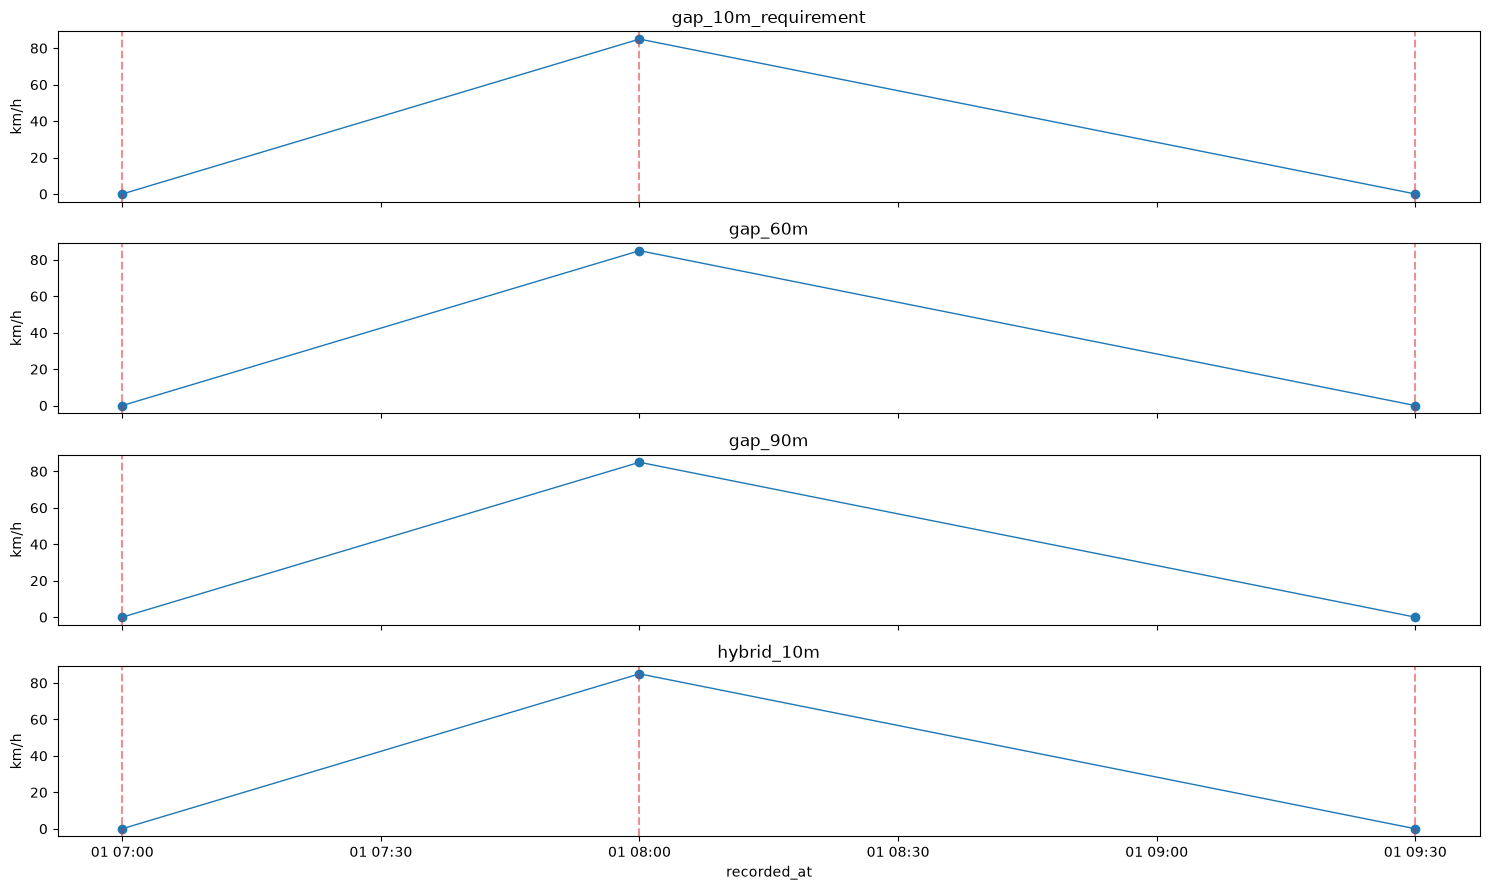

In [34]:
import matplotlib.pyplot as plt 
if plt is not None:
    fig, axes = plt.subplots(len(sample_experiments), 1, figsize=(15, 9), sharex=True)
    for axis, experiment_name in zip(axes, sample_experiments):
        sample = sample_timeline.loc[sample_timeline.experiment.eq(experiment_name)]
        axis.plot(sample.recorded_at, sample.speed_kmh, marker='o', linewidth=1)
        for boundary_at in sample.loc[sample.is_new_trip, 'recorded_at']:
            axis.axvline(boundary_at, color='tab:red', alpha=0.5, linestyle='--')
        axis.set_title(experiment_name)
        axis.set_ylabel('km/h')
    axes[-1].set_xlabel('recorded_at')
    plt.tight_layout()
    plt.show()
else:
    print('Install matplotlib to display timeline charts.')

## 11. Summary visualizations

กราฟสรุปด้านล่างใช้ DataFrame ที่คำนวณไว้แล้ว และไม่เขียนข้อมูลลง disk.

In [ ]:
# Source profile: typical sampling gap and engine-state availability.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

events.groupby('source')['gap_minutes'].median().plot.bar(
    ax=axes[0], color='steelblue', title='Median sampling gap by source'
)
axes[0].set_xlabel('source')
axes[0].set_ylabel('minutes')
axes[0].tick_params(axis='x', rotation=0)

engine_profile['engine_coverage_pct'].plot.bar(
    ax=axes[1], color='seagreen', title='Engine-state coverage by source'
)
axes[1].set_xlabel('source')
axes[1].set_ylabel('percent')
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Compare all candidate segments with trips retained after the 2-minute filter.
sources = sorted(comparison['source'].unique())
fig, axes = plt.subplots(1, len(sources), figsize=(17, 5))

for axis, source in zip(axes, sources):
    source_result = comparison.loc[comparison['source'].eq(source)]
    source_result.plot.bar(
        x='experiment',
        y=['candidate_trips', 'trips_after_2m_filter'],
        ax=axis,
        title=source,
    )
    axis.set_xlabel('')
    axis.set_ylabel('trip count')
    axis.tick_params(axis='x', rotation=55)

plt.suptitle('Candidate segments vs retained trips', y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# Production TripSegmenter output: only trips that pass minimum duration are present.
retained_by_gap = (
    production_benchmark.groupby(['gap_minutes', 'source'])
    .size()
    .unstack(fill_value=0)
)

retained_by_gap.plot(marker='o', figsize=(9, 5))
plt.title('Retained production trips after 2-minute filter')
plt.xlabel('gap threshold (minutes)')
plt.ylabel('trip count')
plt.xticks(retained_by_gap.index)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(retained_by_gap)